# Multi-Disease Chest X-Ray Classification using DenseNet121

This notebook builds a transfer-learning model on **DenseNet121** to classify chest X-ray images into multiple lung conditions (e.g., Normal, Pneumonia, COVID-19, Tuberculosis). It covers data setup, preprocessing, model definition, training, and evaluation.

## 1. Mount Google Drive
Connect Google Drive (for storing the dataset and model checkpoints) and install required packages.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q kaggle scikit-learn

Mounted at /content/drive


## 2. Download and Store the Dataset
Download the chest X-ray dataset from Kaggle and back it up to Google Drive for persistence across sessions.

In [ ]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jtiptj/chest-xray-pneumoniacovid19tuberculosis
!unzip -q chest-xray-pneumoniacovid19tuberculosis.zip -d /content/chest_xray_multi

print("Dataset downloaded successfully!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
License(s): other
100% 1.74G/1.74G [00:14<00:00, 127MB/s]

Dataset downloaded successfully!


In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/Lung_Multi_Disease_Dataset"
os.makedirs(drive_path, exist_ok=True)

shutil.copytree("/content/chest_xray_multi", drive_path, dirs_exist_ok=True)
print("Dataset saved to Google Drive at:", drive_path)

Dataset saved to Google Drive at: /content/drive/MyDrive/Lung_Multi_Disease_Dataset


## 3. Import Libraries
Load TensorFlow/Keras, evaluation utilities, and visualization libraries, and fix random seeds for reproducibility.

In [ ]:
import tensorflow as tf
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Fix randomness
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("Libraries loaded!")

Libraries loaded!


## 4. Data Loading and Augmentation
Set up `ImageDataGenerator` pipelines for training (with augmentation), validation, and testing, and generate class labels from the folder structure.

In [ ]:
train_dir = "/content/chest_xray_local/train"
test_dir  = "/content/chest_xray_local/test"

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)

Found 5378 images belonging to 4 classes.
Found 948 images belonging to 4 classes.
Found 771 images belonging to 4 classes.
Class indices: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TURBERCULOSIS': 3}
Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']


## 5. Build the DenseNet121 Model
Load DenseNet121 pretrained on ImageNet as a frozen feature extractor, and attach a custom classification head.

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,220 (27.35 MB)

 Trainable params: 131,716 (514.52 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 6. Copy Dataset to Local Storage
Copy the dataset from Google Drive to local Colab storage to speed up data loading during training.

In [2]:
import shutil
import os

# Copy dataset from Drive to local Colab (much faster)
local_path = "/content/chest_xray_local"

if not os.path.exists(local_path):
    print("Copying dataset to local storage... Please wait")
    shutil.copytree(
        "/content/drive/MyDrive/Lung_Multi_Disease_Dataset",
        local_path
    )
    print("Copy completed!")
else:
    print("Dataset already in local storage")

Copying dataset to local storage... Please wait
Copy completed!


## 7. Train the Model
Train the model with early stopping and checkpointing, saving the best-performing weights to Drive.

In [ ]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/multi_disease_cnn_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.5135 - loss: 1.3239
Epoch 1: val_accuracy improved from None to 0.74578, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.6043 - loss: 1.0414 - val_accuracy: 0.7458 - val_loss: 0.5709
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.7320 - loss: 0.6787
Epoch 2: val_accuracy improved from 0.74578 to 0.86287, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 142s 841ms/step - accuracy: 0.7577 - loss: 0.6182 - val_accuracy: 0.8629 - val_loss: 0.3852
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8047 - loss: 0.5038
Epoch 3: val_accuracy improved from 0.86287 to 0.87553, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 139s 823ms/step - accuracy: 0.8083 - loss: 0.4972 - val_accuracy: 0.8755 - val_loss: 0.3305
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.8244 - loss: 0.4389
Epoch 4: val_accuracy improved from 0.87553 to 0.89873, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 140s 831ms/step - accuracy: 0.8263 - loss: 0.4450 - val_accuracy: 0.8987 - val_loss: 0.2944
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8417 - loss: 0.4017
Epoch 5: val_accuracy did not improve from 0.89873
169/169 ━━━━━━━━━━━━━━━━━━━━ 136s 807ms/step - accuracy: 0.8449 - loss: 0.3943 - val_accuracy: 0.8945 - val_loss: 0.2737
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8527 - loss: 0.3703
Epoch 6: val_accuracy did not improve from 0.89873
169/169 ━━━━━━━━━━━━━━━━━━━━ 136s 801ms/step - accuracy: 0.8540 - loss: 0.3659 - val_accuracy: 0.8945 - val_loss: 0.2671
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8638 - loss: 0.3546
Epoch 7: val_accuracy improved from 0.89873 to 0.90823, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 140s 829ms/step - accuracy: 0.8648 - loss: 0.3497 - val_accuracy: 0.9082 - val_loss: 0.2448
Epoch 8/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.8755 - loss: 0.3325
Epoch 8: val_accuracy did not improve from 0.90823
169/169 ━━━━━━━━━━━━━━━━━━━━ 135s 798ms/step - accuracy: 0.8654 - loss: 0.3427 - val_accuracy: 0.9082 - val_loss: 0.2375
Epoch 9/10
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.8739 - loss: 0.3364
Epoch 9: val_accuracy did not improve from 0.90823
169/169 ━━━━━━━━━━━━━━━━━━━━ 140s 826ms/step - accuracy: 0.8741 - loss: 0.3291 - val_accuracy: 0.8935 - val_loss: 0.2438
Epoch 10/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.8752 - loss: 0.3229
Epoch 10: val_accuracy improved from 0.90823 to 0.92194, saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5



Epoch 10: finished saving model to /content/drive/MyDrive/multi_disease_cnn_best.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 144s 853ms/step - accuracy: 0.8732 - loss: 0.3273 - val_accuracy: 0.9219 - val_loss: 0.2310


## 8. Evaluate on Test Set
Measure overall test accuracy and loss on the held-out test set.

In [ ]:
loss, accuracy = model.evaluate(test_gen)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 870ms/step - accuracy: 0.8379 - loss: 0.3801

Final Test Accuracy: 83.79%


## 9. Classification Report and Confusion Matrix
Generate predictions on the test set and review per-class performance via a classification report and confusion matrix.

25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 841ms/step

========== Classification Report ==========

               precision    recall  f1-score   support

      COVID19       0.94      0.80      0.87       106
       NORMAL       0.90      0.64      0.75       234
    PNEUMONIA       0.79      0.96      0.86       390
TURBERCULOSIS       0.90      0.93      0.92        41

     accuracy                           0.84       771
    macro avg       0.89      0.83      0.85       771
 weighted avg       0.85      0.84      0.83       771



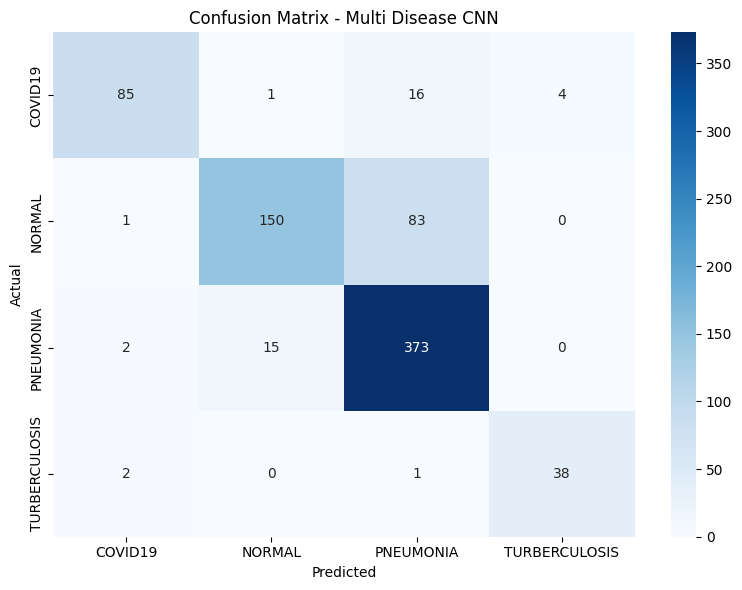

In [ ]:
# Get predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# Classification Report
print("\n========== Classification Report ==========\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Multi Disease CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cnn_confusion_matrix.png", dpi=150)
plt.show()

## 10. Visualize Training History
Plot training vs. validation accuracy and loss curves to check for overfitting or underfitting.

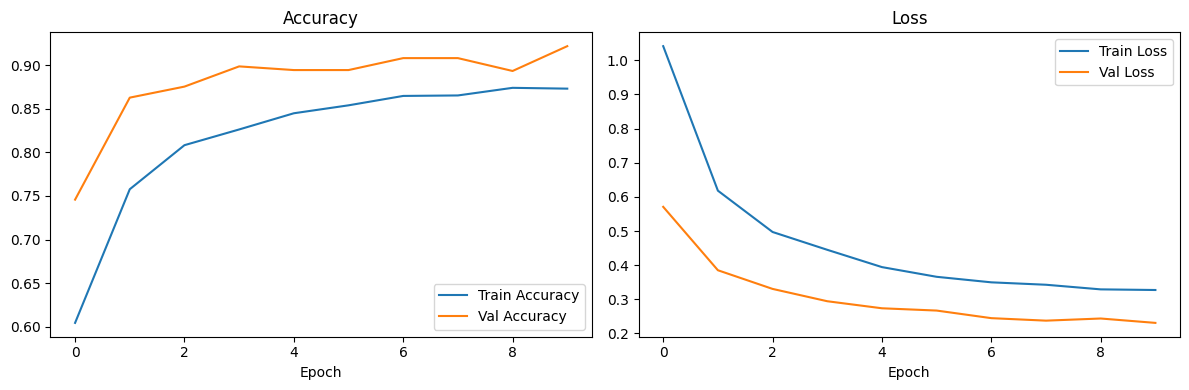

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/cnn_training_history.png", dpi=150)
plt.show()

## 11. Save the Final Model
Persist the trained model to Google Drive for later inference or deployment.

In [ ]:
model.save("/content/drive/MyDrive/multi_disease_cnn_final.h5")
print("Final model saved to Google Drive!")

Final model saved to Google Drive!
